# The Public-Company Founder: A Tax Bill You Can't Pay Without Moving the Stock

**Scenario.** A founder owns 20% of a publicly traded company with a market cap of \$5B. Over one year the company grows to \$7B. The founder's paper gain is \$400M and a 20% annual mark-to-market tax produces an \$80M cash bill. He has no other liquid wealth — his stake *is* his wealth.

He has to sell stock to pay the tax. The question this notebook tries to answer: **how much of the tax does he actually pay, once you include the price impact of forcing \$80M of insider supply through a stock that trades \$30–\$50M a day?**

Short version: the headline 20% tax rate on his paper gain ends up costing him 30–35% of the gain in real economic terms — about 1.5–1.7× the nominal rate — because every dollar of forced selling permanently lowers the value of the stock he still owns.

## A note on the model

Two serious bodies of empirical work disagree about the shape of the permanent-impact function. The qualitative story (forced selling produces nontrivial permanent value destruction) holds under both. The exact multiplier on the headline tax depends on which model you pick.

- **Almgren, Thum, Hauptmann & Li (2005)** — ~30k Citigroup institutional brokerage orders. They explicitly **reject** the square-root model. From their abstract: *"We reject the common square-root model for temporary impact as function of trade rate, in favor of a 3/5 power law across the range of order sizes considered."* For permanent impact they find a **linear** function of order size with a turnover correction:
$$I = \gamma\,\sigma\,\frac{X}{V}\left(\frac{\Theta}{V}\right)^{1/4}, \qquad J - \frac{I}{2} = \eta\,\sigma\left(\frac{X}{VT}\right)^{3/5}$$
with γ = 0.314, η = 0.142. *I* is the permanent price drop, *J* is the average realized cost on the trade, *X* is order size, *V* is daily volume, *Θ* is shares outstanding, *T* is execution duration in days, σ is daily volatility.

- **Tóth, Lemperière, Deremble, de Lataillade, Kockelkoren & Bouchaud (2011, Phys. Rev. X)** — derive a square-root impact law from a *latent order book* model and provide additional empirical support from CFM's own trade data. They build on a long line of earlier work (Loeb 1983; Barra 1997; Lillo, Farmer & Mantegna 2003, *Nature*; Bouchaud, Gefen, Potters & Wyart 2004) that found concave power-law impact, often consistent with $\sqrt{X/V}$. The square-root law is widely treated as the industry workhorse.

We compute under **both models** and present them side by side. They disagree by roughly 2× on the permanent impact at our headline order size, which is why we don't claim a single "right" effective tax rate.

Both papers' calibrations are based on orders ≤ a few percent of daily volume. Our scenario pushes orders of ~160% of daily volume — well outside both calibration ranges. The numbers below should be read as order-of-magnitude estimates, not precise predictions.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

In [2]:
# --- Scenario ------------------------------------------------------
founder_ownership = 0.20
start_market_cap  = 5_000_000_000     # year-start
end_market_cap    = 7_000_000_000     # year-end
tax_rate          = 0.20

# --- Market microstructure ----------------------------------------
adv_pct           = 0.007             # daily $ volume as fraction of market cap (mid/small-cap typical)
sigma_daily       = 0.02              # daily volatility (~30%/sqrt(252))

# Almgren et al. (2005) coefficients (linear permanent, 3/5 temporary, NOT square-root)
gamma_almgren     = 0.314             # permanent-impact coefficient
eta_almgren       = 0.142             # temporary-impact coefficient
beta_temp         = 0.60              # Almgren's temporary exponent (rejects 1/2)
delta_perm        = 0.25              # (Theta/V) exponent in permanent impact

# Tóth et al. (2011) style square-root coefficient (for comparison)
Y_toth            = 1.0               # universal coefficient ~ O(1) in latent-order-book derivation

# Insider-signaling permanent discount, on top of mechanical impact.
# Neither Almgren nor Tóth specifically models 'insider' supply; mid-cap insider-sale
# event studies find ~1-3% extra permanent move on top of mechanical impact.
insider_signal    = 0.01              # 1% additional permanent

# --- Sale plan ----------------------------------------------------
sale_horizon_days = 60                # ~one calendar quarter
rule144_quarter_cap_pct = 0.01        # 1% of shares outstanding per rolling 3 months

## Step 1 — the headline tax bill

In [3]:
stake_start = founder_ownership * start_market_cap
stake_end   = founder_ownership * end_market_cap
paper_gain  = stake_end - stake_start
tax_owed    = tax_rate * paper_gain

print(f"Founder stake at year start:    ${stake_start:>15,.0f}")
print(f"Founder stake at year end:      ${stake_end:>15,.0f}")
print(f"Paper gain on the year:         ${paper_gain:>15,.0f}")
print(f"Tax owed at 20%:                ${tax_owed:>15,.0f}")

Founder stake at year start:    $  1,000,000,000
Founder stake at year end:      $  1,400,000,000
Paper gain on the year:         $    400,000,000
Tax owed at 20%:                $     80,000,000


## Step 2 — how big is that sale relative to normal trading?

In [4]:
adv_dollar = adv_pct * end_market_cap                    # average daily $ volume
horizon_volume = adv_dollar * sale_horizon_days

naive_shares_to_sell_pct = tax_owed / end_market_cap
tax_vs_daily_vol         = tax_owed / adv_dollar
tax_vs_horizon_vol       = tax_owed / horizon_volume

print(f"Average daily dollar volume:      ${adv_dollar:>15,.0f}")
print(f"Volume over {sale_horizon_days}-day horizon:        ${horizon_volume:>15,.0f}")
print()
print(f"Tax bill as % of company:         {naive_shares_to_sell_pct:>15.2%}")
print(f"Tax bill in days of volume:       {tax_vs_daily_vol:>15.1f} days")
print(f"Tax bill as % of horizon volume:  {tax_vs_horizon_vol:>15.2%}")
print()
weekly_volume = adv_dollar * 5
rule144_cap_one_pct  = rule144_quarter_cap_pct * end_market_cap
rule144_cap_weekly   = weekly_volume
rule144_cap_per_quarter = max(rule144_cap_one_pct, rule144_cap_weekly)
print(f"Rule 144 1%-of-shares cap:          ${rule144_cap_one_pct:>13,.0f}")
print(f"Rule 144 weekly-volume cap:         ${rule144_cap_weekly:>13,.0f}")
print(f"Effective Rule 144 cap (greater):   ${rule144_cap_per_quarter:>13,.0f}")
print(f"Tax bill / Rule-144 cap:            {tax_owed/rule144_cap_per_quarter:>15.2f}x  "
      f"(>1 means more than one quarter required)")

Average daily dollar volume:      $     49,000,000
Volume over 60-day horizon:        $  2,940,000,000

Tax bill as % of company:                   1.14%
Tax bill in days of volume:                   1.6 days
Tax bill as % of horizon volume:            2.72%

Rule 144 1%-of-shares cap:          $   70,000,000
Rule 144 weekly-volume cap:         $  245,000,000
Effective Rule 144 cap (greater):   $  245,000,000
Tax bill / Rule-144 cap:                       0.33x  (>1 means more than one quarter required)


## Step 3 — price impact under the Almgren and Tóth models

Note the model choice: Almgren's permanent impact is **linear** in order size, not square-root. The 3/5 exponent shows up only in temporary impact. For comparison we also compute a Tóth-style square-root model. Both add a 1% permanent insider-signaling discount on top of the mechanical impact.

In [5]:
def almgren_impact(gross_dollar_sale,
                   daily_volume=adv_dollar,
                   sigma=sigma_daily,
                   T_days=sale_horizon_days,
                   mkt_cap=end_market_cap,
                   gamma=gamma_almgren,
                   eta=eta_almgren,
                   beta=beta_temp,
                   delta=delta_perm,
                   signal=insider_signal):
    """Almgren et al. (2005): I = gamma*sigma*(X/V)*(Theta/V)^delta (LINEAR in X),
       J - I/2 = eta*sigma*(X/VT)^beta with beta=3/5 (NOT 1/2)."""
    if gross_dollar_sale <= 0:
        return 0.0, 0.0
    XV = gross_dollar_sale / daily_volume
    Theta_over_V = mkt_cap / daily_volume          # = 1 / daily turnover
    perm_mech = gamma * sigma * XV * Theta_over_V ** delta
    temp_excess = eta * sigma * (XV / T_days) ** beta
    realized_J = perm_mech / 2 + temp_excess
    perm_total = perm_mech + signal
    return perm_total, realized_J

def toth_impact(gross_dollar_sale,
                daily_volume=adv_dollar,
                sigma=sigma_daily,
                Y=Y_toth,
                signal=insider_signal):
    """Toth et al. (2011) square-root permanent impact.
       Realized cost on shares sold modeled as I/2 (sqrt models do not
       separate temp/perm explicitly; this matches Almgren's J = I/2 + small)."""
    if gross_dollar_sale <= 0:
        return 0.0, 0.0
    XV = gross_dollar_sale / daily_volume
    perm_mech = Y * sigma * np.sqrt(XV)
    realized_J = perm_mech / 2
    perm_total = perm_mech + signal
    return perm_total, realized_J

for label, fn in [('Almgren (linear perm, 3/5 temp)', almgren_impact),
                  ('Toth    (square-root perm)    ', toth_impact)]:
    p, j = fn(tax_owed)
    print(f"{label}:  permanent = {p:>6.2%},  realized cost J = {j:>6.2%}")

Almgren (linear perm, 3/5 temp):  permanent =  4.54%,  realized cost J =  1.81%
Toth    (square-root perm)    :  permanent =  3.56%,  realized cost J =  1.28%


## Step 4 — gross sale needed to *net* the tax owed

Selling pushes the price down during execution, so the founder must sell more than \$80M of stock at pre-trade prices to net \$80M of cash. Solve for the gross sale `Q` such that `Q × (1 − J(Q)) = $80M` under each model.

In [6]:
def solve_gross_sale(impact_fn, target_net=tax_owed):
    def shortfall(q):
        _, j = impact_fn(q)
        return q * (1 - j) - target_net
    return brentq(shortfall, target_net, target_net * 5)

results = {}
for name, fn in [('Almgren', almgren_impact), ('Toth', toth_impact)]:
    Q = solve_gross_sale(fn)
    perm, J = fn(Q)
    results[name] = dict(Q=Q, perm=perm, J=J)

for name, r in results.items():
    print(f"--- {name} model ---")
    print(f"  Gross stock sold:    ${r['Q']:>14,.0f}")
    print(f"  Friction (Q - tax):  ${r['Q'] - tax_owed:>14,.0f}")
    print(f"  Realized cost J:     {r['J']:>14.2%}")
    print(f"  Permanent impact:    {r['perm']:>14.2%}")
    print()

--- Almgren model ---
  Gross stock sold:    $    81,498,415
  Friction (Q - tax):  $     1,498,415
  Realized cost J:              1.84%
  Permanent impact:             4.61%

--- Toth model ---
  Gross stock sold:    $    81,042,243
  Friction (Q - tax):  $     1,042,243
  Realized cost J:              1.29%
  Permanent impact:             3.57%



## Step 5 — the loss on the shares he still holds

After the sale, the permanent impact stays in the stock price. His *remaining* shares are worth permanently less. That value destruction is not on his tax return, but it is the largest hidden cost of this whole exercise.

In [7]:
for name, r in results.items():
    fraction_sold = r['Q'] / end_market_cap
    remaining_own = founder_ownership - fraction_sold
    remaining_pre  = remaining_own * end_market_cap
    remaining_post = remaining_own * end_market_cap * (1 - r['perm'])
    r['fraction_sold']   = fraction_sold
    r['remaining_own']   = remaining_own
    r['remaining_pre']   = remaining_pre
    r['remaining_post']  = remaining_post
    r['value_destroyed'] = remaining_pre - remaining_post
    print(f"--- {name} ---")
    print(f"  Ownership sold:                 {fraction_sold:.2%} of company")
    print(f"  Remaining ownership:            {remaining_own:.2%}")
    print(f"  Remaining stake pre-impact:     ${remaining_pre:>14,.0f}")
    print(f"  Remaining stake post-impact:    ${remaining_post:>14,.0f}")
    print(f"  Value destroyed on remainder:   ${r['value_destroyed']:>14,.0f}")
    print()

--- Almgren ---
  Ownership sold:                 1.16% of company
  Remaining ownership:            18.84%
  Remaining stake pre-impact:     $ 1,318,501,585
  Remaining stake post-impact:    $ 1,257,704,301
  Value destroyed on remainder:   $    60,797,284

--- Toth ---
  Ownership sold:                 1.16% of company
  Remaining ownership:            18.84%
  Remaining stake pre-impact:     $ 1,318,957,757
  Remaining stake post-impact:    $ 1,271,843,280
  Value destroyed on remainder:   $    47,114,477



## Step 6 — total economic cost vs. headline tax bill

In [8]:
rows = []
for name, r in results.items():
    cost = tax_owed + (r['Q'] - tax_owed) + r['value_destroyed']
    r['total_cost'] = cost
    r['eff_rate']   = cost / paper_gain
    rows.append((
        name,
        tax_owed / 1e6,
        (r['Q'] - tax_owed) / 1e6,
        r['value_destroyed'] / 1e6,
        cost / 1e6,
        f"{r['eff_rate']:.1%}",
        f"{r['eff_rate']/tax_rate:.2f}x",
    ))
summary = pd.DataFrame(rows, columns=[
    'Model', 'Cash to Treasury ($M)', 'Sale friction ($M)',
    'Permanent loss on remaining stake ($M)', 'Total cost ($M)',
    'Effective rate on gain', 'Multiple of nominal',
])
print(summary.to_string(index=False))

  Model  Cash to Treasury ($M)  Sale friction ($M)  Permanent loss on remaining stake ($M)  Total cost ($M) Effective rate on gain Multiple of nominal
Almgren                   80.0            1.498415                               60.797284       142.295699                  35.6%               1.78x
   Toth                   80.0            1.042243                               47.114477       128.156720                  32.0%               1.60x


## Charts

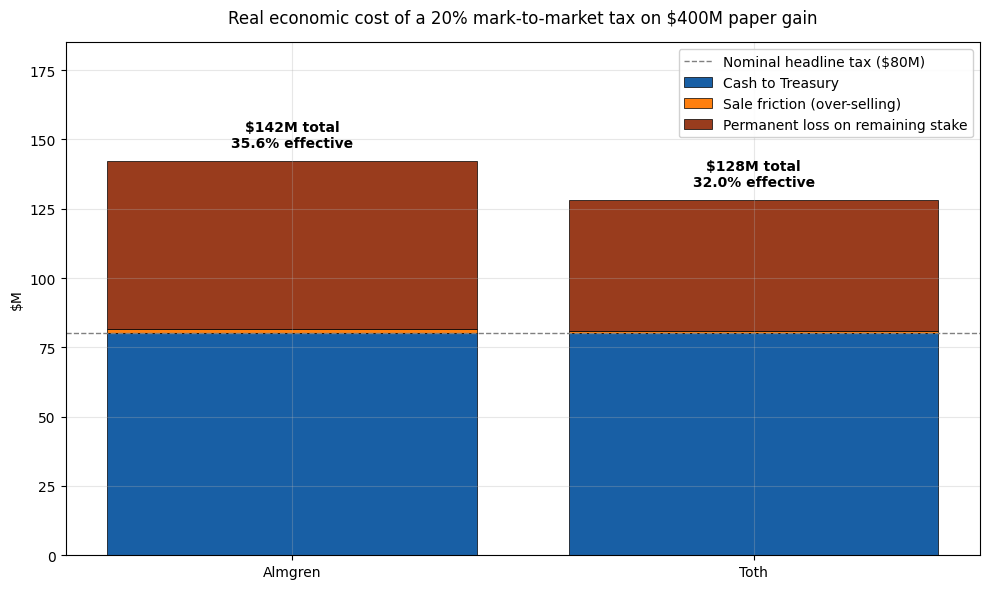

In [9]:
# Stacked bars: real economic cost under each model, with the nominal headline shown for reference.
models = list(results.keys())
cash_part   = [tax_owed/1e6 for _ in models]
friction    = [(results[m]['Q'] - tax_owed)/1e6 for m in models]
destruction = [results[m]['value_destroyed']/1e6 for m in models]
totals      = [c + f + d for c, f, d in zip(cash_part, friction, destruction)]

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(models))
ax.bar(x, cash_part,   color='#185FA5', label='Cash to Treasury',
       edgecolor='black', linewidth=0.5)
ax.bar(x, friction,    bottom=cash_part, color='#ff7f0e',
       label='Sale friction (over-selling)', edgecolor='black', linewidth=0.5)
ax.bar(x, destruction, bottom=[c+f for c,f in zip(cash_part, friction)],
       color='#993C1D', label='Permanent loss on remaining stake',
       edgecolor='black', linewidth=0.5)
ax.axhline(tax_owed/1e6, color='gray', linestyle='--', linewidth=1,
           label=f'Nominal headline tax (${tax_owed/1e6:.0f}M)')

# Totals labeled ABOVE each bar; headroom added to ylim so they clear the title.
for i, total in enumerate(totals):
    ax.text(i, total + 4,
            f'${total:,.0f}M total\n{results[models[i]]["eff_rate"]*100:.1f}% effective',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_title('Real economic cost of a 20% mark-to-market tax on $400M paper gain', pad=14)
ax.set_ylabel('$M')
ax.set_ylim(0, max(totals) * 1.30)             # headroom for labels
ax.legend(loc='upper right', framealpha=0.9)   # away from labels
plt.tight_layout()
plt.show()

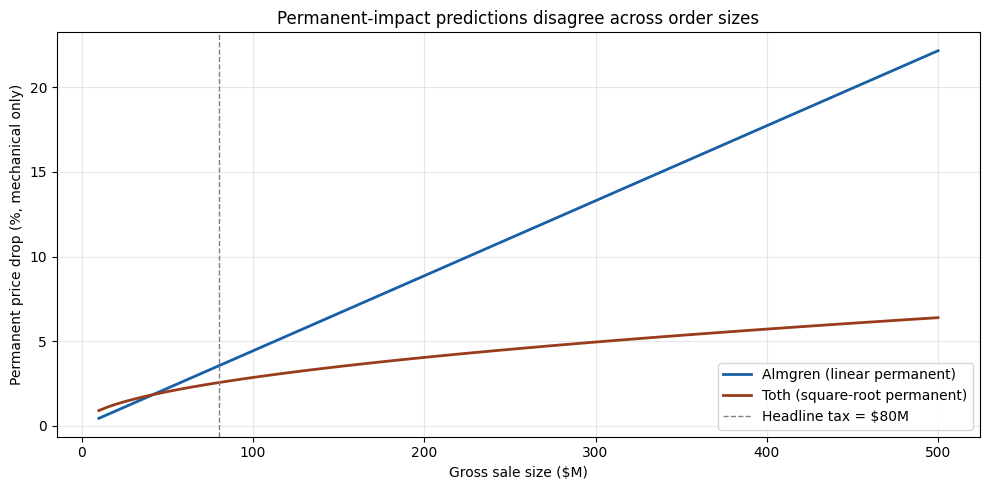

In [10]:
# Side-by-side: Almgren vs Toth permanent-impact predictions across order sizes.
Q_grid = np.linspace(10e6, 500e6, 100)
perm_alm  = np.array([almgren_impact(q, signal=0.0)[0]*100 for q in Q_grid])  # mechanical only
perm_toth = np.array([toth_impact(q, signal=0.0)[0]*100 for q in Q_grid])

fig, ax = plt.subplots()
ax.plot(Q_grid/1e6, perm_alm,  color='#185FA5', linewidth=2, label='Almgren (linear permanent)')
ax.plot(Q_grid/1e6, perm_toth, color='#993C1D', linewidth=2, label='Toth (square-root permanent)')
ax.axvline(tax_owed/1e6, color='gray', linestyle='--', linewidth=1,
           label=f'Headline tax = ${tax_owed/1e6:.0f}M')
ax.set_title('Permanent-impact predictions disagree across order sizes')
ax.set_xlabel('Gross sale size ($M)')
ax.set_ylabel('Permanent price drop (%, mechanical only)')
ax.legend()
plt.tight_layout()
plt.show()

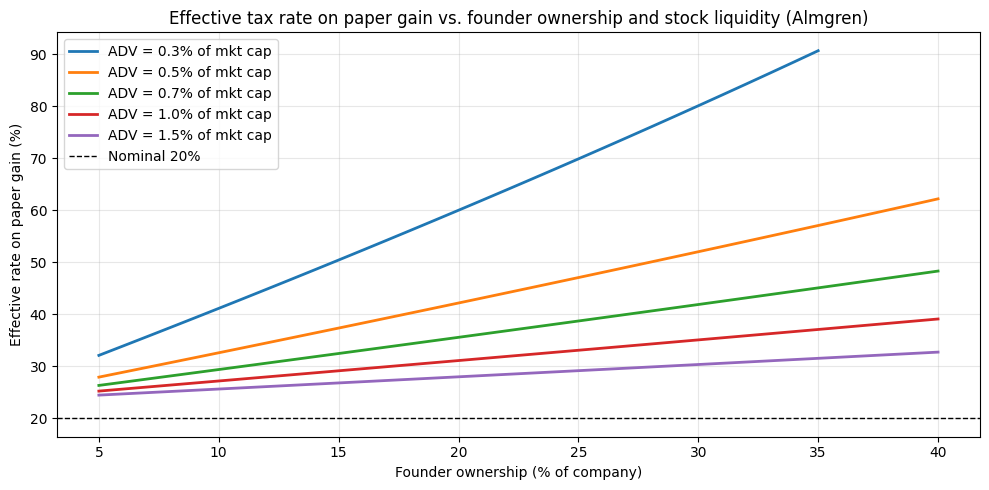

In [11]:
# Sensitivity (Almgren model): effective rate vs founder ownership, sliced by ADV.
ownerships = np.linspace(0.05, 0.40, 36)
adv_pcts   = np.array([0.003, 0.005, 0.007, 0.010, 0.015])

fig, ax = plt.subplots()
for a in adv_pcts:
    eff_rates = []
    for own in ownerships:
        gain = own * (end_market_cap - start_market_cap)
        tax  = tax_rate * gain
        adv_d = a * end_market_cap
        def fn(q): return almgren_impact(q, daily_volume=adv_d)
        try:
            Q = brentq(lambda q: q * (1 - fn(q)[1]) - tax, tax, tax * 10)
        except ValueError:
            eff_rates.append(np.nan); continue
        perm, _ = fn(Q)
        rem_own = own - Q/end_market_cap
        vd = rem_own * end_market_cap * perm
        cost = tax + (Q - tax) + vd
        eff_rates.append(cost / gain)
    ax.plot(ownerships*100, np.array(eff_rates)*100,
            label=f'ADV = {a*100:.1f}% of mkt cap', linewidth=2)

ax.axhline(tax_rate*100, color='black', linestyle='--', linewidth=1, label=f'Nominal {tax_rate:.0%}')
ax.set_title('Effective tax rate on paper gain vs. founder ownership and stock liquidity (Almgren)')
ax.set_xlabel('Founder ownership (% of company)')
ax.set_ylabel('Effective rate on paper gain (%)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

 Year  Mkt cap end ($M)  Ownership (%)  Tax owed ($M)  Economic cost ($M)  Eff. rate on gain (%)
    1            7000.0           18.8           80.0               142.3                   35.6
    2            7540.8           18.5           26.4                56.0                   42.4
    3            8124.9           18.2           27.9                58.9                   42.2
    4            8756.1           17.8           29.5                62.0                   42.0
    5            9438.0           17.5           31.2                65.2                   41.8
    6           10175.1           17.2           33.0                68.7                   41.6


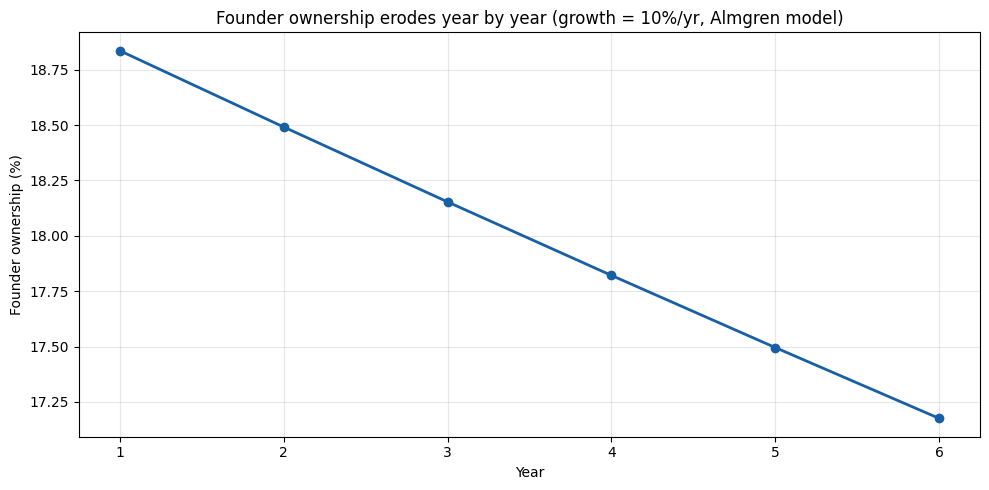

In [12]:
# Multi-year compounding under the Almgren model.
years = 6
growth_per_year = 0.10
alm = results['Almgren']
mc  = end_market_cap
own = founder_ownership - alm['fraction_sold']
rows = [(1, mc/1e6, own*100, tax_owed/1e6, alm['total_cost']/1e6, alm['eff_rate']*100)]
for y in range(2, years+1):
    new_mc = mc * (1 + growth_per_year)
    gain   = own * (new_mc - mc)
    tax    = tax_rate * gain
    adv_d  = adv_pct * new_mc
    def fn(q, _adv=adv_d, _mc=new_mc): return almgren_impact(q, daily_volume=_adv, mkt_cap=_mc)
    Q = brentq(lambda q: q * (1 - fn(q)[1]) - tax, tax, tax * 10)
    perm, _ = fn(Q)
    rem_own = own - Q/new_mc
    vd = rem_own * new_mc * perm
    cost = tax + (Q - tax) + vd
    mc  = new_mc * (1 - perm)
    own = rem_own
    rows.append((y, mc/1e6, own*100, tax/1e6, cost/1e6, cost/gain*100))

trace = pd.DataFrame(rows, columns=['Year', 'Mkt cap end ($M)', 'Ownership (%)',
                                    'Tax owed ($M)', 'Economic cost ($M)', 'Eff. rate on gain (%)'])
print(trace.round(1).to_string(index=False))

fig, ax = plt.subplots()
ax.plot(trace['Year'], trace['Ownership (%)'], marker='o', linewidth=2, color='#185FA5')
ax.set_title(f'Founder ownership erodes year by year (growth = {growth_per_year:.0%}/yr, Almgren model)')
ax.set_xlabel('Year')
ax.set_ylabel('Founder ownership (%)')
plt.tight_layout()
plt.show()

## Takeaways

1. **The \$80M nominal tax bill costs the founder \$120M–\$140M in real economic terms**, depending on which empirical impact model you use. Either way the hidden value-destruction on his remaining stake is comparable to or larger than the cash paid to the Treasury.
2. **The effective tax rate on his paper gain is ~30–35%, not 20%.** And it climbs sharply as the company gets smaller, the founder owns more, or the stock is less liquid — exactly the households the proposal is supposed to target.
3. **The model uncertainty is real.** Almgren et al. (2005) reject the square-root law; Tóth et al. (2011) derive it from a latent-order-book model. Both are serious empirical work. Our scenario (~160% of daily volume in a single tax year) is well outside both papers' calibration ranges. The *qualitative* story is robust to model choice; the precise multiplier on the headline tax is not.
4. **Rule 144 doesn't bind for a normally liquid \$5–7B stock** (the weekly-volume cap is roughly \$245M, comfortably above the \$80M sale). But it *does* bind for thinly traded names: cut ADV below ~0.3% of market cap and the founder runs out of legal selling capacity inside one quarter.
5. **Other shareholders pay too.** The permanent price drop applies to *everyone* who owns the stock — index funds, pension plans, retail. A wealth tax on the founder is, in part, a value transfer from every other holder of the same security to the Treasury.
6. **Compounding.** If the company keeps growing, the same dance repeats every year. Ownership erodes monotonically; the founder loses control of the company on a fixed schedule independent of business performance.

## Caveats

- **Almgren et al. (2005) explicitly reject the square-root law** for temporary impact (β = 0.600 ± 0.038 vs. 1/2), and find permanent impact *linear* in order size with a (Θ/V)^¼ turnover correction. We use their actual functional form here, not the "square root" caricature sometimes attributed to them.
- The square-root law is well-supported by a *separate* and equally serious body of work — most prominently **Tóth et al. (2011, Phys. Rev. X)**, which derives it from a latent-order-book mechanism. Earlier supporting work includes Loeb (1983), Barra (1997), Lillo, Farmer & Mantegna (2003), and Bouchaud, Gefen, Potters & Wyart (2004). We compute under both models and show the disagreement.
- The +1% insider-signaling permanent discount is a stylized addition above mechanical impact. Pre-announced 10b5-1 plan sales attract less; surprise insider supply attracts more.
- Both calibrations are for orders ≤ a few percent of daily volume. Our scenario is at ~160% of daily volume. Read the numbers as order-of-magnitude estimates, not point predictions.

## Sources

- Almgren, R., Thum, C., Hauptmann, E., & Li, H. (2005). *Direct estimation of equity market impact.* ([PDF](https://www.cis.upenn.edu/~mkearns/finread/costestim.pdf)) — fits linear permanent impact, **rejects** the square-root model for temporary impact in favor of β = 3/5.
- Tóth, B., Lemperière, Y., Deremble, C., de Lataillade, J., Kockelkoren, J., & Bouchaud, J.-P. (2011). *Anomalous price impact and the critical nature of liquidity in financial markets.* Phys. Rev. X 1, 021006. ([arXiv 1105.1694](https://arxiv.org/abs/1105.1694)) — derives the square-root law from a latent-order-book mechanism.
- Lillo, F., Farmer, J. D., & Mantegna, R. N. (2003). *Master curve for price-impact function.* Nature 421, 129–130.
- Bouchaud, J.-P., Gefen, Y., Potters, M., & Wyart, M. (2004). *Fluctuations and response in financial markets.* Quantitative Finance 4(2), 176–190.
- Frazzini, A., Israel, R., & Moskowitz, T. (2018). *Trading costs.* AQR working paper. ([SSRN 3229719](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=3229719)) — \$1.7T of live trade data, finds real-world trading costs an order of magnitude lower than prior literature.
- SEC Rule 144 — selling restricted and control securities ([SEC.gov](https://www.sec.gov/reports/rule-144-selling-restricted-control-securities)).